In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = '/content/drive/My Drive/Waste_Data.zip'
extract_path = '/content/Waste_Data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


print("Extracted files:")
os.listdir(extract_path)

Extracted files:


['Non_Recyclable', 'Recyclable']

In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split

src_dir = '/content/Waste_Data'
categories = ['Recyclable', 'Non_Recyclable']


base_dir = '/content/split_data_tt'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')



os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
for category in categories:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(test_dir, category), exist_ok=True)


for category in categories:
    src_path = os.path.join(src_dir, category)

    files = []
    for root, _, filenames in os.walk(src_path):
        for f in filenames:
            files.append(os.path.join(root, f))


    if not files:
        print(f"Warning: No files in {src_path}. Skipping.")
        continue

    train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

    for file_list, dest_dir in [(train_files, train_dir), (test_files, test_dir)]:
        for f in file_list:
            relative_path = os.path.relpath(f, src_path)
            dest_path = os.path.join(dest_dir, category, relative_path)
            os.makedirs(os.path.dirname(dest_path), exist_ok=True)
            shutil.copy(f, dest_path)

print("Splitting complete!")
for category in categories:
    print(f"Train {category}: {len(os.listdir(os.path.join(train_dir, category)))}")
    print(f"Test {category}: {len(os.listdir(os.path.join(test_dir, category)))}")

Splitting complete!
Train Recyclable: 1768
Test Recyclable: 443
Train Non_Recyclable: 1625
Test Non_Recyclable: 407


Image shape: (384, 512, 3)
Image shape: (384, 512, 3)
Image shape: (384, 512, 3)
Image shape: (384, 512, 3)
Image shape: (150, 150, 3)
Image shape: (150, 150, 3)
Image shape: (150, 150, 3)
Image shape: (150, 150, 3)


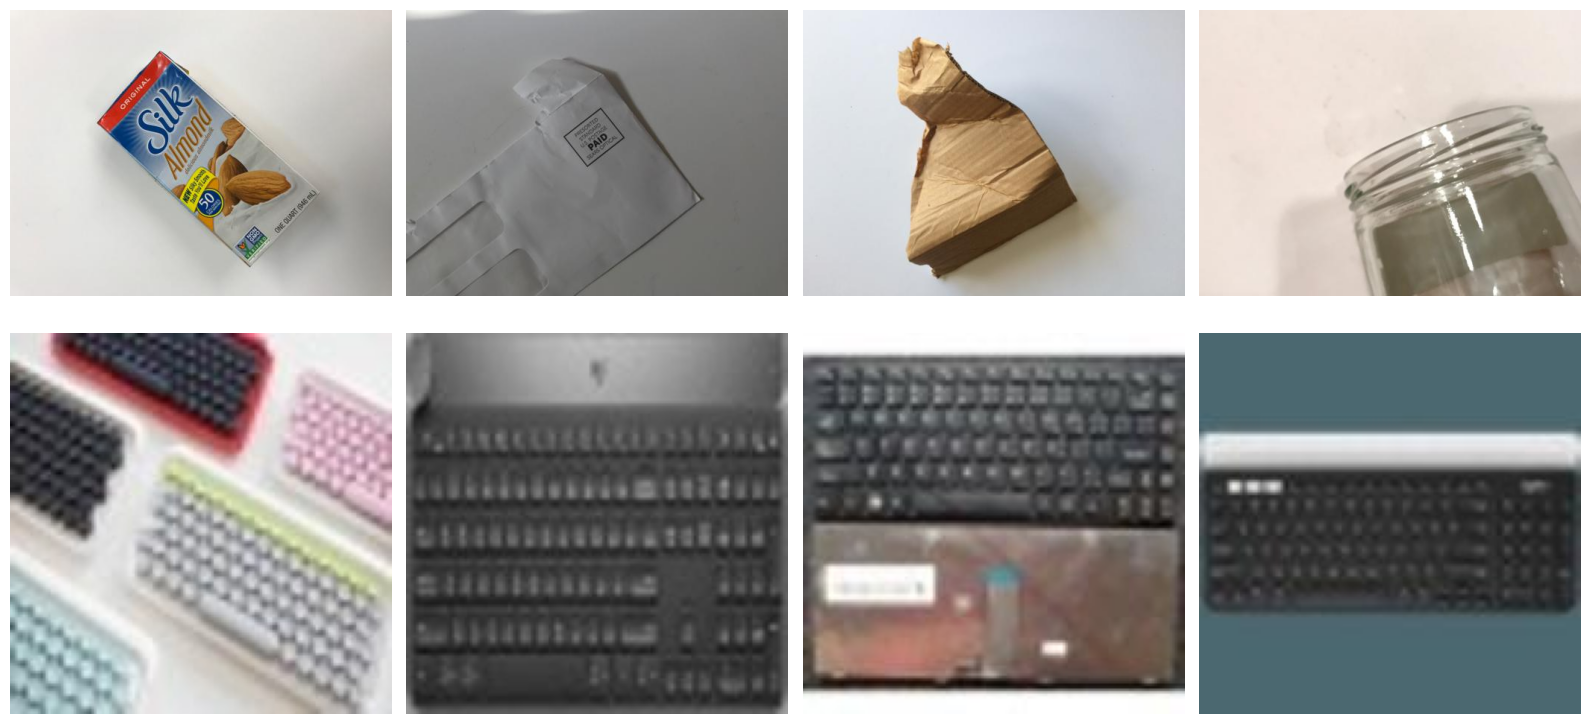

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

train_recyclable_dir = '/content/split_data_tt/train/Recyclable'
train_non_recyclable_dir = '/content/split_data_tt/train/Non_Recyclable'

train_recyclable_fnames = os.listdir(train_recyclable_dir)
train_non_recyclable_fnames = os.listdir(train_non_recyclable_dir)
train_non_recyclable_fnames.sort()

%matplotlib inline

nrows, ncols = 2, 4
pic_index = 0
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index += 4
next_recyclable_pix = [os.path.join(train_recyclable_dir, fname)
                      for fname in train_recyclable_fnames[pic_index-4:pic_index]]
next_non_recyclable_pix = [os.path.join(train_non_recyclable_dir, fname)
                         for fname in train_non_recyclable_fnames[pic_index-4:pic_index]]

for i, img_path in enumerate(next_recyclable_pix + next_non_recyclable_pix):
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off')
    img = mpimg.imread(img_path)
    plt.imshow(img)
    print(f"Image shape: {img.shape}")

plt.tight_layout()
plt.show()

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/split_data_tt/train',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    '/content/split_data_tt/test',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)
print(f"Training samples: {train_generator.samples}")
print(f"Test samples: {test_generator.samples}")


Found 3393 images belonging to 2 classes.
Found 850 images belonging to 2 classes.
Class mapping: {'Non_Recyclable': 0, 'Recyclable': 1}
Training samples: 3393
Test samples: 850


In [6]:
imgs, labels = next(train_generator)
print(imgs.shape)


(32, 224, 224, 3)


In [7]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

img_height, img_width = 224, 224

model = models.Sequential([
    layers.InputLayer(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Model built and compiled successfully.")


Model built and compiled successfully.


In [8]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/Colab Notebooks/my_final_model.h5')
print("✅ Model loaded successfully!")





✅ Model loaded successfully!


In [9]:
# Evaluate on test data
test_results = model.evaluate(test_generator)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall: {test_results[3]:.4f}")


27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.9012 - loss: 0.2396 - precision: 0.8844 - recall: 0.9323
Test Loss: 0.2396
Test Accuracy: 0.9012
Test Precision: 0.8844
Test Recall: 0.9323


In [10]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,563 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step


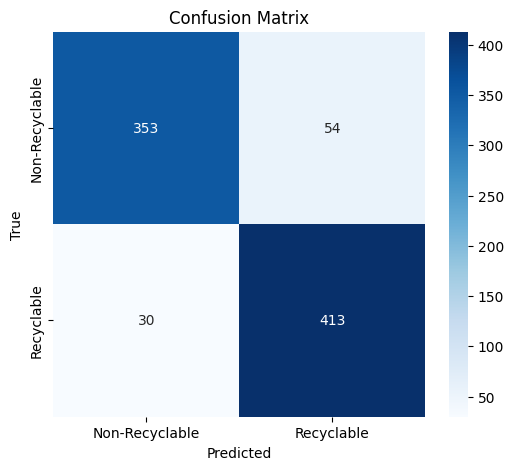

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get true labels and predicted labels
y_true = test_generator.classes
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Recyclable', 'Recyclable'],
            yticklabels=['Non-Recyclable', 'Recyclable'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [12]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.title('Training Loss and Accuracy')
plt.show()


NameError: name 'history' is not defined

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


In [ ]:
model.save('best_waste_classifier.keras')  # New recommended format
print(f"\nTraining samples used: {train_generator.samples}")
if 'val_generator' in locals():
    print(f"Validation samples used: {val_generator.samples}")

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/my_model.keras')
